# Semantic IDs with RQ-VAE

Load the **trained** RQ-VAE and its Semantic IDs over a 3-domain catalog
(Musical Instruments / Video Games / Office Products). Items that mean similar
things share their leading codes.

*Kernel: select `nanoTIGER (mps)` (top-right) so everything runs on the Apple GPU.*


In [1]:
# --- setup + device check -------------------------------------------------
import sys; sys.path.append('..')
import json, platform
from collections import defaultdict
import numpy as np, torch
import matplotlib.pyplot as plt
from config import cfg, DATA, OUT
from common import get_device, seed_everything
from checkpoints import load_rqvae
from demo_pipeline import ensure_trained

print('arch:', platform.machine(), '| torch:', torch.__version__,
      '| mps:', torch.backends.mps.is_available())
seed_everything(cfg.seed)
device = get_device()

arch: arm64 | torch: 2.4.1 | mps: True
[device] using mps


In [2]:
# --- train once, then reuse ----------------------------------------------
# First run trains the full pipeline (RQ-VAE + RecGPT) and saves out/*.pt;
# later runs just load the checkpoints.
ensure_trained()

[demo] using existing embeddings at /Users/gballoccu/Desktop/SemanticIDs/notebooks/../data/item_emb.npy
[demo] RQ-VAE already trained
[demo] RecGPT already trained


{'items': PosixPath('/Users/gballoccu/Desktop/SemanticIDs/notebooks/../data/items.jsonl'),
 'sequences': PosixPath('/Users/gballoccu/Desktop/SemanticIDs/notebooks/../data/sequences.json'),
 'semantic_ids': PosixPath('/Users/gballoccu/Desktop/SemanticIDs/notebooks/../data/semantic_ids.json'),
 'rqvae': PosixPath('/Users/gballoccu/Desktop/SemanticIDs/notebooks/../out/rqvae.pt'),
 'recgpt': PosixPath('/Users/gballoccu/Desktop/SemanticIDs/notebooks/../out/recgpt.pt')}

In [3]:
# --- load the trained artifacts ------------------------------------------
import re
def short_name(text):
    m = re.search(r'<item_name>\s*(.*?)\s*</item_name>', text)
    return (m.group(1) if m else text)[:34]

items = [json.loads(l) for l in open(DATA / 'items.jsonl')]
items.sort(key=lambda r: r['item'])
names = [short_name(r['text']) for r in items]       # parse <item_name> tag
cats  = [r.get('category') for r in items]

sem   = json.load(open(DATA / 'semantic_ids.json'))
codes = np.array(sem['ids'])                          # (N, D) trained Semantic IDs
emb   = np.load(DATA / 'item_emb.npy')
rqvae = load_rqvae(OUT / 'rqvae.pt', device)          # reload the trained quantizer
print(len(names), 'items | Semantic ID length =', codes.shape[1],
      '| codebook size =', sem['codebook_size'])

3600 items | Semantic ID length = 4 | codebook size = 128


In [4]:
# --- health: is the codebook actually used? ------------------------------
# Dead-code revival keeps levels from collapsing onto a couple of codes.
for l in range(sem['n_levels']):
    used = len(np.unique(codes[:, l]))
    print(f'codebook {l}: {used:>3}/{sem["codebook_size"]} codes used')
uniq = len({tuple(r) for r in codes})
print(f'unique code tuples: {uniq}/{len(codes)}')

codebook 0: 114/128 codes used
codebook 1: 119/128 codes used
codebook 2:  77/128 codes used
unique code tuples: 3600/3600


In [5]:
# --- an item is now a tuple of codes -------------------------------------
for i in range(8):
    print(tuple(codes[i]), ' ', names[i], f'[{cats[i]}]')

(6, 21, 48, 0)   Yamaha Nylon Guitar Lite [Musical_Instruments]
(6, 104, 98, 0)   Yamaha Overdrive Pedal Mk II [Musical_Instruments]
(33, 38, 76, 0)   Zildjian Tube Amplifier 2024 [Musical_Instruments]
(1, 123, 76, 0)   Fender Condenser Microphone [Musical_Instruments]
(38, 95, 38, 0)   Pearl Dreadnought Guitar XL [Musical_Instruments]
(1, 11, 56, 0)   Fender Instrument Cable Mini [Musical_Instruments]
(6, 41, 21, 0)   Yamaha Hi-Hat Cymbals 2024 [Musical_Instruments]
(11, 55, 107, 0)   Korg Overdrive Pedal [Musical_Instruments]


**The payoff.** Group items by their *first* code — each group is one coherent domain.


In [6]:
# --- what shares a first code? (clusters, by name) ------------------------
groups = defaultdict(list)
for i, c in enumerate(codes):
    groups[int(c[0])].append(i)

for c0, members in sorted(groups.items(), key=lambda kv: -len(kv[1]))[:6]:
    doms = {cats[i] for i in members}
    print(f'\n── first code = {c0}   ({len(members)} items, domains: {doms}) ──')
    for i in members[:5]:
        print(f'   {tuple(codes[i])}  {names[i]:34s} [{cats[i]}]')


── first code = 103   (63 items, domains: {'Video_Games'}) ──
   (103, 29, 46, 0)  SteelSeries Memory Card XL         [Video_Games]
   (103, 103, 56, 0)  SteelSeries Memory Card 2024       [Video_Games]
   (103, 91, 98, 0)  SteelSeries Fight Stick Pro        [Video_Games]
   (103, 57, 67, 0)  SteelSeries VR Headset             [Video_Games]
   (103, 78, 105, 0)  SteelSeries Memory Card            [Video_Games]

── first code = 33   (62 items, domains: {'Musical_Instruments'}) ──
   (33, 38, 76, 0)  Zildjian Tube Amplifier 2024       [Musical_Instruments]
   (33, 31, 106, 0)  Zildjian Digital Piano             [Musical_Instruments]
   (33, 84, 101, 0)  Zildjian Hi-Hat Cymbals XL         [Musical_Instruments]
   (33, 15, 38, 0)  Zildjian Overdrive Pedal XL        [Musical_Instruments]
   (33, 17, 47, 0)  Zildjian Synthesizer 2024          [Musical_Instruments]

── first code = 109   (62 items, domains: {'Video_Games'}) ──
   (109, 38, 119, 0)  Microsoft Charging Dock            [Video_G

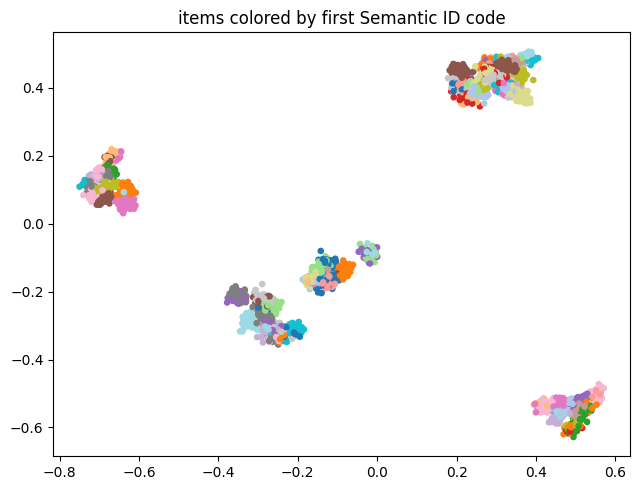

In [7]:
# --- see it in 2D ---------------------------------------------------------
xm = emb - emb.mean(0)
_, _, Vt = np.linalg.svd(xm, full_matrices=False)
p2 = xm @ Vt[:2].T
plt.figure(figsize=(6.5, 5))
plt.scatter(p2[:, 0], p2[:, 1], c=codes[:, 0], cmap='tab20', s=14)
plt.title('items colored by first Semantic ID code'); plt.tight_layout(); plt.show()

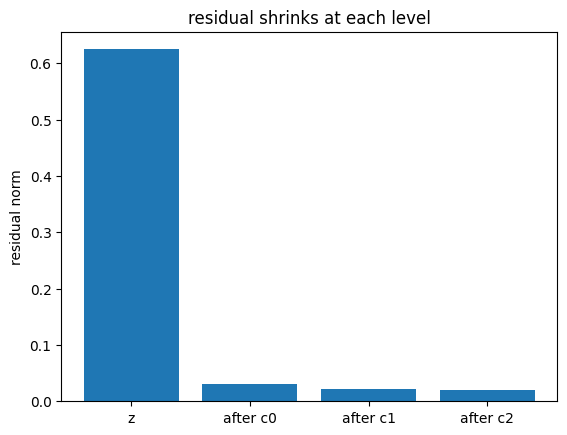

In [8]:
# --- residual quantization, visualized ------------------------------------
x0 = torch.tensor(emb[:1], device=device)
with torch.no_grad():
    z = rqvae.encoder(x0); r = z; norms = [z.norm().item()]
    for vq in rqvae.quantizers:
        q, _, _, _ = vq(r); r = r - q; norms.append(r.norm().item())
plt.bar(range(len(norms)), norms)
plt.xticks(range(len(norms)), ['z'] + [f'after c{l}' for l in range(len(norms) - 1)])
plt.ylabel('residual norm'); plt.title('residual shrinks at each level'); plt.show()